# Laboratorio 5
In questo laboratorio costruiremo un sistema RAG completo utilizzando il dataset MaartenGr/arxiv_nlp di Hugging Face, che contiene abstract di articoli NLP da arXiv.
L’obiettivo è creare un assistente che possa rispondere a domande sulla letteratura scientifica in NLP, citando le fonti.
## 1. Installazione librerie necessarie
- datasets: per caricare il dataset da Hugging Face
- sentence-transformers: per generare embeddings semantici
- faiss: vector database per retrieval efficiente
- transformers: per il modello generativo locale
- torch: backend per i modelli
- rank_bm25: per il retrieval lessicale BM25
- matplotlib: per visualizzare le distribuzioni delle similarità

In [23]:
%pip install datasets transformers sentence-transformers faiss-cpu torch accelerate matplotlib rank_bm25

In [24]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import faiss
from huggingface_hub import login
from dotenv import load_dotenv
import os
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

print(f"PyTorch: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch: 2.11.0+cu128
Device: CUDA


## 2. Caricamento Dataset
Importazione delle risorse da arXiv

In [25]:
print("Caricamento dataset arXiv NLP...")
dataset = load_dataset("MaartenGr/arxiv_nlp", split="train")
df = pd.DataFrame(dataset)

print(f"Documenti caricati: {len(df)}")
print(f"Colonne: {df.columns.tolist()}")
df.head(2)

Caricamento dataset arXiv NLP...
Documenti caricati: 44949
Colonne: ['Titles', 'Abstracts', 'Years', 'Categories']


,Titles,Abstracts,Years,Categories
0,Introduction to Arabic Speech Recognition Usin...,In this paper Arabic was investigated from t...,2007,Computation and Language
1,Arabic Speech Recognition System using CMU-Sph...,In this paper we present the creation of an ...,2007,Computation and Language


In [26]:
# Prepara documenti
documents = []
metadata = []

# Auto-rileva colonne (gestisce varianti del dataset)
title_col = next((c for c in df.columns if 'title' in c.lower()), df.columns[0])
abstract_col = next((c for c in df.columns if 'abstract' in c.lower() or 'summar' in c.lower()), df.columns[1])

print(f"Colonna titolo: {title_col}")
print(f"Colonna abstract: {abstract_col}\n")

# Riempimento delle strutture dati con i dati rilevati dal dataset
# Combiniamo titolo e abstract perché sono semanticamente coesi
for idx, row in df.iterrows():
    title = str(row[title_col]) if pd.notna(row[title_col]) else 'No Title'
    abstract = str(row[abstract_col]) if pd.notna(row[abstract_col]) else 'No Abstract'

    documents.append(f"Title: {title}\n\nAbstract: {abstract}")
    metadata.append({
        'title': title,
        'year': str(row.get('year', 'Unknown'))
    })

print(f"Documenti preparati: {len(documents)}")
print(f"\nEsempio:\n{documents[0][:300]}...")

Colonna titolo: Titles
Colonna abstract: Abstracts

Documenti preparati: 44949

Esempio:
Title: Introduction to Arabic Speech Recognition Using CMUSphinx System

Abstract:   In this paper Arabic was investigated from the speech recognition problem
point of view. We propose a novel approach to build an Arabic Automated Speech
Recognition System (ASR). This system is based on the open sou...


## 3. Generazione Embeddings
Utilizziamo il modello `all-MiniLM-L6-v2` di Sentence Transformers per generare embeddings semantici dei documenti.

In [27]:
print("Caricamento modello di embedding...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Generazione embeddings...")
embeddings = embed_model.encode(
    documents,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(f"\nEmbeddings shape: {embeddings.shape}")

Caricamento modello di embedding...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generazione embeddings...


Batches:   0%|          | 0/1405 [00:00<?, ?it/s]


Embeddings shape: (44949, 384)


## 4. Vector Store (FAISS)
Creiamo un indice FAISS per il retrieval efficiente dei documenti basato sugli embeddings generati. Utilizziamo un indice di tipo `IndexFlatIP`, che calcola il prodotto interno (Inner Product) tra i vettori, utile per misurare la similarità coseno. E' ottimale per le ricerche esatte nel dataset.

In [28]:
# Crea indice FAISS
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print(f"Indice FAISS creato: {index.ntotal} vettori")

Indice FAISS creato: 44949 vettori


## 5. Retriever
Funzione di recupero dei documenti più rilevanti dato un input di query. La funzione `retrieve` prende una query testuale, la trasforma in embedding e cerca i k documenti più simili nell'indice FAISS.

In [29]:
def retrieve(query, k=5):
    """Recupera i k documenti più rilevanti"""
    query_emb = embed_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    similarities, indices = index.search(query_emb, k)

    results = []
    for i, (sim, idx) in enumerate(zip(similarities[0], indices[0])):
        results.append({
            'rank': i + 1,
            'doc_id': int(idx),
            'similarity': float(sim),
            'document': documents[idx],
            'metadata': metadata[idx]
        })
    return results

# Test retrieval
test_query = "What are transformer models?"
results = retrieve(test_query, k=3)

print(f"Query: {test_query}\n")
for r in results:
    print(f"[{r['rank']}] Similarity: {r['similarity']:.3f}")
    print(f"    {r['metadata']['title'][:80]}")
    print()

Query: What are transformer models?

[1] Similarity: 0.679
    Transformer models: an introduction and catalog

[2] Similarity: 0.532
    CoTFormer: More Tokens With Attention Make Up For Less Depth

[3] Similarity: 0.499
    Neutron: An Implementation of the Transformer Translation Model and its
  Varian



## 6. Hybrid search
Utilizziamo un approccio ibrido combinando BM25 e FAISS.
BM25 è un modello di rappresetnazione dei documenti tramite vettori di frequenze: estende tf-idf tramite l'introduzione della saturazione (dopo a un certo punto, aumentare la frequenza non aumenta significativamente il peso).

La funzione `hybrid_retrieve` calcola i punteggi di entrambi i metodi, li normalizza e li fonde per ottenere un ranking finale. Per lo score di ranking viene utilizzata la formula:
$score(q,d) = \alpha \cdot BM25(q,d) + (1 - \alpha) \cdot similarity(q,d)$

$\alpha$ è un paramentro che bilancia le due parti ed è un valore compreso tra 0 e 1.

Il processo si articola in più fasi:
- Si calcolano singolarmente i punteggi di BM25 (lessicale) e di FAIIS (semantico) per tutti i documenti
- Si riordinano i punteggi di FAIIS in modo da essere compatibile con BM25, il quale restituisce i punteggi con gli indici ordinati
- Si normalizzano i due punteggi tramite la funzione normalize(); di solito i punteggi di di BM25 prevalgono su quelli di FAIIS, dunque è un operazione che serve a renderli confontabili, evitando uno squilibrio
- Si calcola lo score di ranking e si stampano i primi risultati.

In [30]:
from rank_bm25 import BM25Okapi

# Tokenizzazione in words dei documenti
tokenized_corpus = [doc.split(" ") for doc in documents]
bm25 = BM25Okapi(tokenized_corpus)

# Funzione di normalizzazione
def normalize(scores):
    scores = np.array(scores)
    if scores.max() == scores.min():
        return np.zeros_like(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())

# Funzione di Hybrid Search dei primi k risultati
def hybrid_retrieve(query, k=5, alpha=0.5):
    """ Recupera i k documenti più rilevanti combinando BM25 e FAISS. """
    # Puntaggio BM250
    tokenized_query = query.split(" ")
    bm25_scores = bm25.get_scores(tokenized_query)

    # Punteggio FAISS
    embedded_query = embed_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    faiss_scores, faiss_indices = index.search(embedded_query, len(documents))

    # Riordinamento dei punteggi FAISS per allinearli con BM25
    sim_full = np.zeros(len(documents))
    for sim, idx in zip(faiss_scores[0], faiss_indices[0]):
        sim_full[idx] = sim

    # Normalizzazione
    bm25_scores_normalized = normalize(bm25_scores)
    faiss_scores_normalized = normalize(sim_full)

    # Calcolo punteggio di ranking
    score = alpha * bm25_scores_normalized + (1 - alpha) * faiss_scores_normalized
    top_k_idx = np.argsort(score)[::-1][:k]

    # Stampa dei risultati
    results = []
    for rank, doc_idx in enumerate(top_k_idx):
        results.append({
            'rank': rank + 1,
            'doc_id': int(doc_idx),
            'score': float(score[doc_idx]),
            'document': documents[doc_idx],
            'metadata': metadata[doc_idx]
        })
    return results

## 7. Re-ranking
La funzione `reranking()` è stata creata per scegliere, tra i risultati ottenuti dall'hybrid search, i risultati più rilevanti.
Vengono passati i risultati dell'hybrid search con la variabile `risultati_hybrid`.

Si usa `CrossEncoder` come modello di reranking, per calcolare il punteggio di rerank tra query e ogni documento. Questo indica l'affinità tra i due. I risultati vengono ordinati in base al punteggio di rerank e ne vengono restituiti solo i primi k.

In [31]:
from sentence_transformers import CrossEncoder
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

def reranking(query, risultati_hybrid, top_k=5):
    """ Funzione di re-ranking dei risultati dell'hybrid search """
    # Crea la coppia query-documento per ogni risultato dell'hybrid search
    coppie_query_documents = [(query, risultati["document"]) for risultati in risultati_hybrid]

    # Restituisce un array di coppie di punteggi per ogni coppia query-documento
    # Li assegniamo a ogni coppia corrispondente
    risultati_rerank = reranker.predict(coppie_query_documents)
    for c, score in zip(risultati_hybrid, risultati_rerank):
        c['cross_score'] = float(score)

    # Riordiniamo i risultati
    reranked = sorted(risultati_hybrid, key=lambda x: x['cross_score'], reverse=True)[:top_k]

    # Assegniamo la posizione al campo rank del risultato
    for i, r in enumerate(reranked):
        r['rank'] = i + 1

    return reranked

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

## 8. Test set e Precision@k
Creiamo un test set e valutiamo l'accuratezza di un sistema RAG di rilevare k documenti che siano pertinenti con la query con la misura Precision@k. La formula è la seguente:
$\frac{\text{Elementi Rilevanti nei primi } k}{k}$

Per la creazione del test set, si è deciso di usare un criterio basato sulla presenza di una parola chiave nei documenti con la funzione `relevance()`. Se la parola chiave è presente in un documento, allora quel documento è considerato rilevante per la query corrispondente.

Iterando sul test set, si recuperano i risultati di retrieval, hybrid search e re-ranking per ogni query. La precision viene calcolata per ciascun metodo e stampata a video.

Nella variabile p la precision restituisce i 5 documenti che sono più affini alla query, quindi applicando la formula:
doc rilevanti dei primi k risultati/k -> rilevanti trovati / 5

In [32]:
def precision(results, relevant_ids, k=5):
    """ Calcola la precision@k per un insieme di risultati. """
    top_k = results[:k]

    relevant_retrieved = 0
    for r in top_k:
        if r['doc_id'] in relevant_ids:
            relevant_retrieved += 1

    return relevant_retrieved / k

def relevance(keyword):
    """ Determina i documenti rilevanti ottenuti in base a una parola chiave. """
    relevant = set()
    for i, doc in enumerate(documents):
        if keyword.lower() in doc.lower():
            relevant.add(i)
    return relevant

# Creazione del test set con coppie query-documenti_rilevanti per quella query
test_set = {
    "Explain the attention mechanism in transformer": relevance("attention"),
    "Could you explain what a Generative Pre-trained Transformer is": relevance("GPT"),
    "What is a speech recognition task?": relevance("speech recognition"),
    "What is a gold standard?": relevance("gold standard"),
    "Could you explain why a treebank is": relevance("tree bank")
}

# Testing della ricerca
for query, relevant_ids in test_set.items():
    risultati_retrieve = retrieve(query, k=200)
    risultati_hybrid = hybrid_retrieve(query, k=200, alpha=0.5)
    risultati_hybrid_rr = hybrid_retrieve(query, k=300, alpha=0.5)
    risultati_reranking = reranking(query, risultati_hybrid_rr, top_k=200)

    # Gestiamo l'assenza di documenti rilevanti
    if len(relevant_ids) == 0:
        print(f" Documenti rilevanti non disponibili per la query:  {query}\n")
        break

    p_retrieve = precision(risultati_retrieve, relevant_ids, k=90)
    p_hybrid = precision(risultati_hybrid, relevant_ids, k=90)
    p_reranking = precision(risultati_reranking, relevant_ids, k=90)

    # Stampiamo i risultati ottenuti
    print(f"Query: {query}")
    print(f"\tNumero di doc rilevanti: {len(relevant_ids)}")
    print(f"\tPrecision@k retrieve: {p_retrieve:.2f}")
    print(f"\tPrecision@k hybrid search: {p_hybrid:.2f}")
    print(f"\tPrecision@k re-ranking: {p_reranking:.2f}\n")

Query: Explain the attention mechanism in transformer
	Numero di doc rilevanti: 5075
	Precision@k retrieve: 0.96
	Precision@k hybrid search: 0.97
	Precision@k re-ranking: 1.00

Query: Could you explain what a Generative Pre-trained Transformer is
	Numero di doc rilevanti: 3358
	Precision@k retrieve: 0.22
	Precision@k hybrid search: 0.31
	Precision@k re-ranking: 0.44

Query: What is a speech recognition task?
	Numero di doc rilevanti: 1504
	Precision@k retrieve: 0.62
	Precision@k hybrid search: 0.90
	Precision@k re-ranking: 0.93

Query: What is a gold standard?
	Numero di doc rilevanti: 192
	Precision@k retrieve: 0.11
	Precision@k hybrid search: 0.31
	Precision@k re-ranking: 0.74

Query: Could you explain why a treebank is
	Numero di doc rilevanti: 9
	Precision@k retrieve: 0.01
	Precision@k hybrid search: 0.00
	Precision@k re-ranking: 0.01



## 8. LLM Local
Utilizziamo un modello LLM locale per generare risposte basate sui documenti recuperati.
In questo caso, scegliamo il modello Phi2.

In [34]:
model_phi = "microsoft/phi-2"

print(f"Caricamento {model_phi}...")

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_phi)
model = AutoModelForCausalLM.from_pretrained(
    model_phi,
    dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None,
    low_cpu_mem_usage=True
)

llm = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    device=0 if device == "cuda" else -1,
    max_new_tokens=300,
)

print(f"Modello caricato su {device}")

Caricamento microsoft/phi-2...


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

Modello caricato su cuda


## 9. Sistema RAG Completo
Implementazione del sistema rag completo con hybrid search e reranking. La funzione `rag_answer()` prende in input una query, recupera i documenti più rilevanti, costruisce un contesto e genera una risposta basata su di esso.

In [35]:
def rag_answer(query, k=5, verbose=True, temperature = 0.7):
    """Risponde alla query usando RAG system"""

    if verbose:
        print(f"Query: {query}\n")
        print("=" * 60)
        print("RETRIEVAL")
        print("=" * 60)

    # 1. Retrieval
    hybrid_results = hybrid_retrieve(query, k=k*2)
    results = reranking(query, hybrid_results, top_k=k)

    if verbose:
        for r in results:
            print(f"[{r['rank']}] {r['metadata']['title'][:70]}")
            print(f"\tSimilarity: {r['cross_score']:.3f}")

    # 2. Costruisci contesto
    context_parts = []
    for r in results:
        context_parts.append(f"[Document {r['rank']}]\n{r['document']}")
    context = "\n\n".join(context_parts)

    # Limita contesto per modelli piccoli
    if len(context) > 1500:
        context = context[:1500] + "\n[...truncated...]"

    # 3. Costruisci prompt
    # Settiamo il template utilizzato da phi2
    # Il template specifico per Phi-2 gestisce system, user e inserisce Instruct/Output
    phi2_template = (
        "{% for message in messages %}"
            "{% if message['role'] == 'system' %}"
                "Instruct: Contesto di sistema: {{ message['content'] }}\n"
            "{% elif message['role'] == 'user' %}"
                "{% if not loop.first and messages[loop.index0 - 1]['role'] != 'system' %}Instruct: {% endif %}"
                "{{ message['content'] }}\nOutput:"
            "{% elif message['role'] == 'assistant' %}"
                "{{ message['content'] }}\n"
            "{% endif %}"
        "{% endfor %}"
    )
    tokenizer.chat_template = phi2_template

    # Template per messaggio
    messages = [
        {
            "role": "system",
            "content": "You are a helpful assistant specialized in NLP research. Answer based on the provided context."
        },
        {
            "role": "user",
            "content": f"""Context from research papers: {context}\n\n
            Question: {query}\n\n
            Answer based on the context above:"""
        }
    ]
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # 4. Genera risposta
    if verbose:
        print("\n" + "=" * 60)
        print("GENERATION")
        print("=" * 60)

    output = llm(
        prompt,
        max_new_tokens=250,
        do_sample=True,
        temperature=temperature,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )

    # Estrai risposta
    full_text = output[0]['generated_text']
    answer = full_text[len(prompt):].strip() if full_text.startswith(prompt) else full_text

    if verbose:
        print("\n" + "=" * 60)
        print("ANSWER")
        print("=" * 60)
        print(answer)
        print("\n" + "=" * 60)
        print("SOURCES")
        print("=" * 60)
        for r in results:
            print(f"- {r['metadata']['title']} ({r['metadata']['year']})")

    return {
        'query': query,
        'answer': answer,
        'sources': results
    }

## 10. Test del Sistema
Testiamo il sistema completo variando temperature e k per osservare come cambia la generazione della risposta. Utilizziamo le tre query proposte.

In [37]:
temps=[0.1, 0.5, 0.9]
ks = [3, 5, 10]
queries = [
    "What is BERT and how does it work?",
    "Explain the attention mechanism in transformers",
    "What are the main differences between BERT and GPT?"
]

for query in queries:
    print(f"Query: {query}\n")
    for tem in temps:
        for k in ks:
            print(f"\tTemperature: {tem} e K: {k}\n")
            ris = rag_answer(query, k=k, temperature = tem)

Query: What is BERT and how does it work?

	Temperature: 0.1 e K: 3

Query: What is BERT and how does it work?

RETRIEVAL


[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] A Primer in BERTology: What we know about how BERT works
	Similarity: 5.867
[2] BERT Cannot Align Characters
	Similarity: 4.472
[3] He Thinks He Knows Better than the Doctors: BERT for Event Factuality

	Similarity: 3.857

GENERATION

ANSWER
BERT is a transformer-based model that has been widely used in NLP research. It has been shown to be effective in aligning cross-lingual sentences on the word level, but its ability to align characters is still limited. The closer two languages are, the better BERT can align them on the character level. However, the proximity of two languages does seem to be a factor, with English being more related to German than to Greek. BERT has been shown to work well in English to Fake-English alignment, but this does not generalize to natural languages to the same extent. Nevertheless, the similarity matrices for natural languages show weaker relations the further apart they are.

SOURCES
- A Primer in BERTology: What we know about how BERT works (Unknow

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] A Primer in BERTology: What we know about how BERT works
	Similarity: 5.867
[2] What do you mean, BERT? Assessing BERT as a Distributional Semantics
 
	Similarity: 5.116
[3] BERT Cannot Align Characters
	Similarity: 4.472
[4] He Thinks He Knows Better than the Doctors: BERT for Event Factuality

	Similarity: 3.857
[5] What does BERT Learn from Multiple-Choice Reading Comprehension
  Data
	Similarity: 3.266

GENERATION

ANSWER
BERT is a popular transformer-based model that has achieved state-of-the-art results in many NLP tasks. It works by learning contextualized word embeddings, which are vector representations for words in context. BERT has been the subject of over 150 studies, and researchers have found that it learns a lot of information about language and how it is represented in the brain. However, there are still many questions about how BERT works and what it can do.

SOURCES
- A Primer in BERTology: What we know about how BERT works (Unknown)
- What do you mean, BERT? Asse

...

[1] FoundationLayerNorm: Scaling BERT and GPT to 1,000 Layers
	Similarity: 0.768
[2] Does BERT look at sentiment lexicon?
	Similarity: 0.683
[3] GATology for Linguistics: What Syntactic Dependencies It Knows
	Similarity: -0.715

GENERATION

ANSWER
BERT and GPT are both deep neural network models used for natural language
processing (NLP) tasks. BERT is a model developed by Google's AI team and is
specifically designed for NLP tasks. GPT, on the other hand, is a model developed
by OpenAI and is also designed for NLP tasks. However, there are several key
differences between BERT and GPT.

Firstly, BERT is designed to be more efficient than GPT. BERT uses a technique
called "masked language modeling" which allows it to train on shorter
sequences of text and still achieve good performance on long-term
recall. GPT, on the other hand, uses a technique called "transformer-based
neural machine translation" which requires it to train on much longer
sequences of text.

Secondly, BERT is designed

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] Adapting GPT, GPT-2 and BERT Language Models for Speech Recognition
	Similarity: 2.745
[2] FoundationLayerNorm: Scaling BERT and GPT to 1,000 Layers
	Similarity: 0.768
[3] Does BERT look at sentiment lexicon?
	Similarity: 0.683
[4] Explaining Translationese: why are Neural Classifiers Better and what 
	Similarity: -0.508
[5] GATology for Linguistics: What Syntactic Dependencies It Knows
	Similarity: -0.715

GENERATION

ANSWER
The main differences between BERT and GPT are that BERT is a bidirectional model, while GPT is unidirectional. Additionally, BERT is pre-trained on a massive amount of text, while GPT is not. Finally, the output probabilities of BERT are no longer valid language prior probabilities, so a conversion method is proposed to compute the correct probabilities.


            Question: How can the combination of the fine-tuned GPT and GPT-2 outperform the combination of three neural LMs trained from scratch?


            Answer based on the context above:
Output: The

[transformers] Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] (Chat)GPT v BERT: Dawn of Justice for Semantic Change Detection
	Similarity: 3.101
[2] Adapting GPT, GPT-2 and BERT Language Models for Speech Recognition
	Similarity: 2.745
[3] Sensitivity Analysis on Transferred Neural Architectures of BERT and
 
	Similarity: 1.239
[4] Feature Engineering vs BERT on Twitter Data
	Similarity: 0.938
[5] FoundationLayerNorm: Scaling BERT and GPT to 1,000 Layers
	Similarity: 0.768
[6] Does BERT look at sentiment lexicon?
	Similarity: 0.683
[7] Explaining Translationese: why are Neural Classifiers Better and what 
	Similarity: -0.508
[8] GATology for Linguistics: What Syntactic Dependencies It Knows
	Similarity: -0.715
[9] What the [MASK]? Making Sense of Language-Specific BERT Models
	Similarity: -2.000
[10] Better than BERT but Worse than Baseline
	Similarity: -2.971

GENERATION

ANSWER
There are several differences between BERT and GPT. Firstly,
BERT is a language model that pre-trains on a large corpus of text to improve
its ability to understand 

I risultati mostrano come la temperatura influenzi la creatività e la variabilità delle risposte generate dal modello. Temperature più basse tendono a produrre risposte più conservative e coerenti, mentre temperature più alte possono generare risposte più varie e creative, ma talvolta meno precise e con allucinazioni, portando il modello a inventare formati estranei (come quiz ed esercizi) e a troncare le frasi.
Allo stesso modo, aumentando il numero k di documenti recuperati, il modello ha accesso a un contesto più ampio, che può migliorare la qualità della risposta, ma introduce rumore includendo documenti a bassa similarità.
Per questo task scientifico, il bilanciamento ottimale per evitare allucinazioni sarebbe un k intermedio unito a una temperatura molto bassa.

## 11. Analisi Retrieval
Analizziamo la distribuzione delle similarità dei documenti recuperati per una query specifica. Questo ci permette di capire come i documenti si distribuiscono in termini di rilevanza rispetto alla query.

In [38]:
# Query di riferimento
query = "What are neural networks?"
results_retrieve = retrieve(query, k=20)
results_hybrid = hybrid_retrieve(query, k=20)
results_hybrid_rr = hybrid_retrieve(query, k=30)
results_reranking = reranking(query, results_hybrid_rr, top_k=20)

# Similarità di ogni risultato
similarities_retrieve = [r['similarity'] for r in results_retrieve]
similarities_hybrid = [r['score'] for r in results_hybrid]
similarities_reranking = [r['cross_score'] for r in results_reranking]

# Rank di rilevanza
ranks_retrieve = [r['rank'] for r in results_retrieve]
ranks_hybrid = [r['rank'] for r in results_hybrid]
ranks_reranking = [r['rank'] for r in results_reranking]

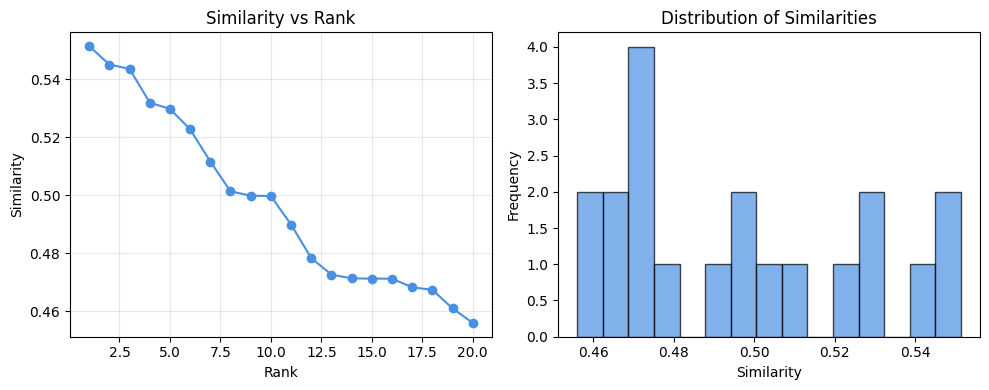

Query: What are neural networks?
Mean similarity: 0.497
Std similarity: 0.030


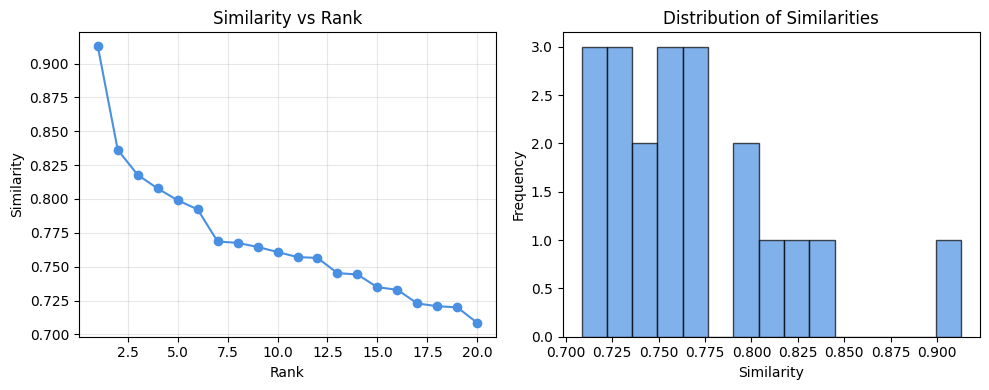

Query: What are neural networks?
Mean similarity: 0.769
Std similarity: 0.047


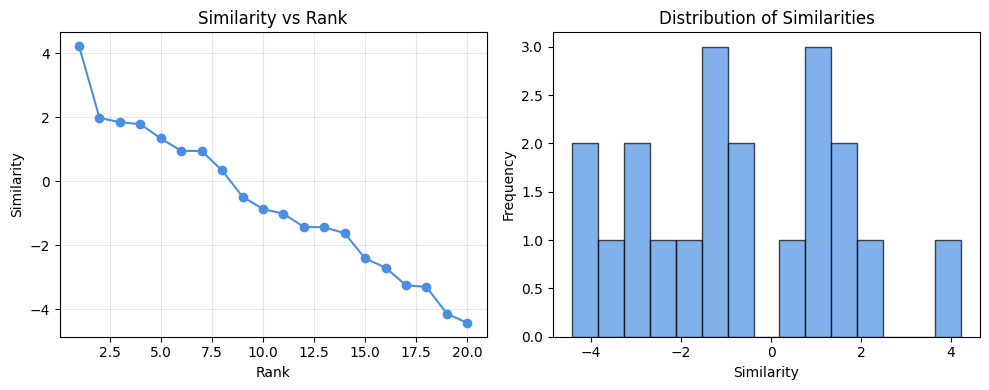

Query: What are neural networks?
Mean similarity: -0.682
Std similarity: 2.262


In [39]:
import matplotlib.pyplot as plt

def graph(ranks, similarities):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(ranks, similarities, 'o-', color='#4A90E2', label='Retrieve')
    plt.xlabel('Rank')
    plt.ylabel('Similarity')
    plt.title('Similarity vs Rank')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(similarities, bins=15, color='#4A90E2', alpha=0.7, edgecolor='black')
    plt.xlabel('Similarity')
    plt.ylabel('Frequency')
    plt.title('Distribution of Similarities')

    plt.tight_layout()
    plt.show()

    print(f"Query: {query}")
    print(f"Mean similarity: {np.mean(similarities):.3f}")
    print(f"Std similarity: {np.std(similarities):.3f}")

graph(ranks_retrieve, similarities_retrieve)
graph(ranks_hybrid, similarities_hybrid)
graph(ranks_reranking, similarities_reranking)